# LAB 1 -- DAY 3B -- NORMAL DISTRIBUTION AND PROBABILITY

Many real-world measurements approximately follow a **normal distribution**, often called a **bell curve**. Examples include people's heights, blood pressure, and body temperature when measured from a large enough sample.

A normal distribution is centered around an average (mean) value. Most measurements are clustered near the average, while values farther from the average become less common.

In this notebook, you will use temperatures from a random sample of 100 RIT students to make predictions about the entire RIT population (approximately 20,000 students). For example, you will estimate:

* How many and what fraction of students have a high fever ($\geq$ 39 $^\circ$C)
* How many students have temperatures in a healthy range (36 $^\circ$C $\leq$ X $\leq$ 38.5 $^\circ$C)
* How many students have unusually low temperatures ($\leq$ 36.0 $^\circ$C)

Rather than measuring every student on campus, we can use a relatively small sample to make estimates about the entire RIT population. This ability to make predictions about an entire population using sample data is one of the biggest advantages of statistics.

Throughout this notebook, you will:

* Read a CSV file containing sample temperature data
* Calculate the sample average and standard deviation
* Use the **norm_dist(poi, avg, sd)** function (explained later) to estimate the probability (fraction) and estimated number of RIT students within different temperature ranges.

# First step, inputting and reading a CSV (data) file

Just like in the previous part (grubbs_test), we are going to input a CSV file so that we can quickly read and organize the data.

Run the following code cell and upload the correct CSV file.

In [1]:
# importing a file from your computer
# using one of google colab's libraries
from google.colab import files

# files.upload() opens a file picker so you can upload a (CSV) file from your computer
# the uploaded file is stored in the Colab session so Python can read the data inside it
# note: you only have to upload once. after that, it should save the file and you can press "cancel upload" to skip this step
# in the case it doesn't save the file, then just reupload.
uploaded = files.upload()

# TODO [+1 pt]
# click run -> choose files -> select 'normdist.csv'
# after it uploads successfully, continue running the remaining cells

Saving normdist.csv to normdist.csv


# Next, we are going to loop through the data in the file and add it to the data list

Here, we create a data_list, open the CSV file, and use a **for loop** to read each row and store each value in the list.

If you need a refresher on reading CSV files or using for loops, refer back to the grubbs_test and calibration_curves notebooks.

In [3]:
# 1. importing csv so we can read our file
import csv

# 2. creating a data_list to store our values
data_list = []

# 3. reading the file line by line and adding each value to data list
# note: if this doesn't work, check the file name is correct. feel free to update if needed
with open("normdist.csv", "r") as f:      # opening "normdist.csv" in read mode using f to call our file

    # 4. uses csv library to read our file f and put into variable called data
    data = csv.reader(f)

    # 5. we are looping through each row in our data.
    for row in data:

      # 6. adding the data (row[0]) into our data list

      # TODO [+1 pt]
      # 1) replace 'pass' with appending the data to the data list [+1 pt]
      data_list.append(float(row[0]))

# printing data_list to confirm it was read correctly
print(data_list)

[36.7, 38.8, 38.4, 36.9, 36.6, 35.6, 38.0, 38.4, 37.5, 37.3, 37.0, 38.0, 37.2, 36.9, 36.7, 36.0, 37.1, 35.3, 38.7, 35.9, 36.8, 35.6, 37.3, 36.2, 35.9, 35.9, 38.1, 38.1, 36.3, 38.1, 38.2, 38.0, 38.1, 36.3, 37.0, 35.3, 35.6, 36.3, 37.6, 37.0, 37.6, 38.2, 36.8, 37.4, 35.8, 38.4, 38.2, 34.0, 38.2, 37.4, 37.0, 37.4, 38.4, 38.2, 36.9, 37.3, 38.2, 36.8, 38.4, 37.1, 36.3, 36.7, 36.2, 39.4, 36.4, 38.6, 37.9, 38.0, 37.8, 37.4, 36.6, 35.9, 34.1, 37.0, 37.6, 37.8, 35.9, 35.3, 34.8, 36.9, 37.1, 36.9, 36.7, 37.1, 36.5, 37.2, 38.0, 37.3, 37.3, 37.1, 38.4, 38.6, 37.7, 36.3, 36.6, 37.6, 38.2, 36.9, 36.7, 39.1]


## Let's take a closer look at a normal distribution (bell curve)

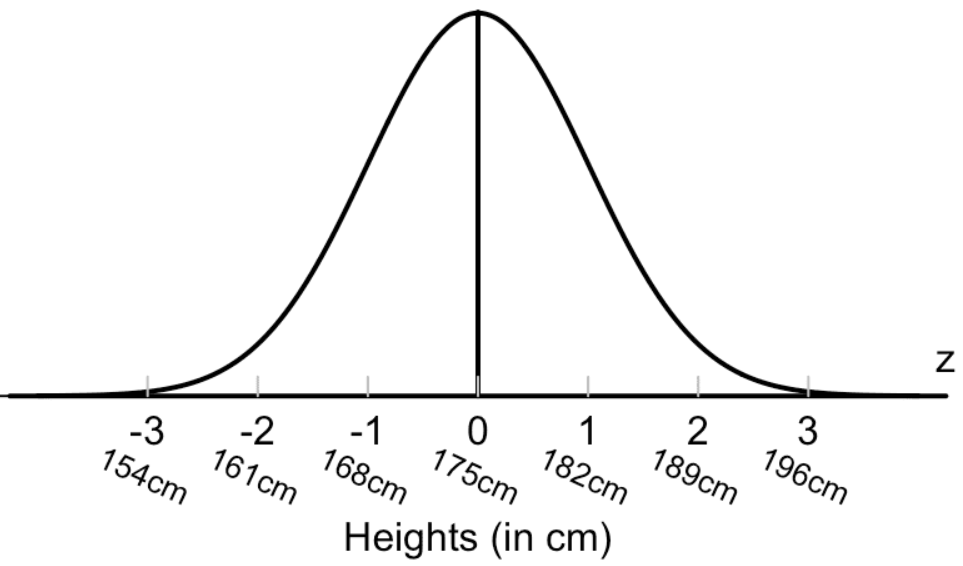

In the example above:
* average height = 175 cm
* standard deviation = 7 cm

Most people have heights close to 175 cm, while values farther from the average become less common. This is why extremely short or tall people are relatively uncommon.

Suppose we want to answer the following question: **What fraction of people are shorter than 169 cm?**

To answer this, we'll use the function:

    norm_dist(poi, avg, sd)

where:
* poi = point of interest
* avg = average of the data
* sd = sample standard deviation

The function returns **P(X $\leq$ poi)**, which represents the probability (or fraction) of values that are less than or equal to the point of interest.

For example: **norm_dist(169, 175, 7)** returns P(X $\leq$ 169), or the fraction of people whose heights are less than or equal to 169 cm.

Throughout this notebook, we'll use this function to estimate both the probability and the expected number of RIT students within different temperature ranges.

Don't forget to run the code for the norm_dist() function below before continuing !!

In [4]:
# @title norm_dist(poi, avg, sd)
# import to use norm function for normal distribution
from scipy.stats import norm

def norm_dist(poi, avg, sd):
  # making sure standard deviation is positive
  if sd <= 0:
    raise ValueError("standard deviation must be positive.")

  # using the scipy.stats norm function to find the normal distribution (cdf)
  return norm.cdf(poi, loc=avg, scale=sd)

## Calculating the sample statistics

To work with a normal distribution, we first need two values:

* sample average (avg)
* sample standard deviation (sd)

In statistics, these are often written as $\bar{x}$ (sample average) and $s$ (sample standard deviation), but in our code we'll simply use the variable names *avg* and *sd*.

Run the two code cells below before continuing. Feel free to read through the code to see how each function works.

In [5]:
# @title average(data_list)
def average(data_list):
  sum = 0                       # init sum to 0
  data_length = len(data_list)  # find number of values in list

  # sum up each value in data_list
  for i in range(data_length):
    sum += data_list[i]         # sum = sum + data_list[i]

  # find the average of the data list
  average = sum / data_length

  # returns average
  return average

In [6]:
# @title sample_sd(data_list)
import math                         # to take square root

def sample_sd(data_list):
  sum_of_deviances = 0              # initialize sum to 0
  data_length = len(data_list)      # find length of data

  # calculate average
  avg = average(data_list)          # use the average() function we created

  # find deviations from mean for each data point
  for i in range(data_length):
    deviation = data_list[i] - avg  # subtract mean from each data point
    squared_d = (deviation ** 2)    # square the deviation to ensure all positive values
    sum_of_deviances += squared_d   # sum all squared deviations

  # divide sum by (n-1) where n is the data_length
  variance = sum_of_deviances / (data_length - 1)

  # take square root to give sample standard deviation and return it
  sample_sd = math.sqrt(variance)
  return sample_sd

## Let's find the avg and sd of the data_list !!

Use the functions below to calculate the sample average and sample standard deviation of data_list:

* **average(data_list)** --> returns the sample average of data_list
* **sample_sd(data_list)** --> returns the sample standard deviation of data_list


In [7]:
# TODO [+2 pts]
# 1) calculate avg [+1 pt]
avg = average(data_list)
# 2) calculate sd [+1 pt]
sd = 33

# printing values found
print(f"avg = {avg} \nsd = {sd}")

avg = 37.123000000000005 
sd = 33


## Probability cheat sheet

Throughout the notebook, we will use the following notation:

```
Notation             Variable Name       Meaning

P(X <= 25)           prob_leq_25         probability less than or equal to 25
P(X >= 25)           prob_geq_25         probability greater than or equal to 25
1 - P(X <= 25)       prob_geq_25         probability greater than or equal to 25
P(20 <= X <= 30)     prob_20_to_30       probability between 20 and 30
```

Note:
* P(X >= 25) = 1 - P(X <= 25)
* **norm_dist(poi, avg, sd)** --> returns the area to the **left** of the point of interest. To find the area to the **right**, use 1 - norm_dist(poi, avg, sd).
* Throughout the notebook, we'll use the variable names above whenever we calculate probabilities.

In [10]:
# find the fraction of students with temps >= 39 C
# norm_dist gives areas to the left (<=) of value
# use variables already created for the avg and sd

# TODO [+2 pts]
# 1) find P(X <= 39) [+1 pt]
prob_leq_39 = norm_dist(39, avg, sd)
# 2) find P(X >= 39) [+1 pt]
prob_geq_39 = 1 - prob_leq_39

# printing percentage or fraction of students with temps >= 39
print(f"P(X >= 39) = {prob_geq_39}")

P(X >= 39) = 0.4773208758865046


## Wait, what's the difference between a fraction of students and the number of students ???

The probabilities we calculate represent fractions of the population, not the actual number of students.

For example, if **P(X $\geq$ 40) = 0.02**, then we estimate that about 2% of RIT students have a temperature of at least 40 $^\circ$.

Since RIT has approximately 20,000 students, we estimate the number of students by multiplying:

      0.02 * 20,000 = 400 students

Throughout the rest of the notebook, we'll use the following naming convention:

```
Variable            Meaning

prob_*              probability (0 to 1)
students_*          estimated # of students (out of 20,000)
```

Here, * represents the rest of the variable name describing the event. For example, prob_geq_39 and students_geq_39 both refer to temperatures greater than or equal to 39 $^\circ$C.

Don't forget to round to the nearest whole student, we can't have an eighth of a student!! (Well... you could, but you might end up in jail after).

Use the function below to round:

* **round(value)** -> returns the value rounded to the nearest whole number


```
# you can multiply and round in the same step by doing:
students_leq_25 = round(prob_leq_25 * 20000)
```




In [11]:
# now find the estimated number of students with a temp >= 39
# make sure you round to the nearest whole number using the round(value) function
# TODO FOR STUDENTS
students_geq_39 = round(prob_geq_39 * 20000)

# printing total number of students with temps >= 39
print(f"estimated # of students with temps >= 39 = {students_geq_39}")


estimated # of students with temps >= 39 = 9546


## What if we want to find the probability between two values?

Suppose we want to find: **P(29 <= X <= 33)**.

The norm_dist() function only returns **P(X $\leq$ poi)**, or the probability to the **left** of the point of interest.

```
|----------------------------------|
0                              P(X<=33)

|-------------|
0         P(X<=29)
```

To find the probability between two values, subtract the smaller probability from the larger one: **P(X<=33) - P(X<=29)**. Subtracting these two probabilities isolates the area between them, resulting in **P(29 <= X <= 33)**.

```
              |---------------------|
          P(X<=29)              P(X<=33)
```


This is written in code as:
```
prob_leq_33 = norm_dist(33, avg, sd)          # P(X<=33)
prob_leq_29 = norm_dist(29, avg, sd)          # P(X<=29)
prob_29_to_33 = prob_leq_33 - prob_leq_29     # P(29 <= X <= 33) = P(X<=33) - P(X<=29)
```

In [14]:
# estimate the number of students with temperatures between 36 and 38.5 °C
# P(X<=38.5) - P(X<=36) gives the fraction of the population between those two values

# TODO [+3 pts]
# 1) find P(X <= 38.5) [+1 pt]
prob_leq_38_5 = 33
# 2) find P(X <= 36) [+1 pt]
prob_leq_36 = 222
# 3) find P(36 <= X <= 38.5) [+1 pt]
prob_36_to_38_5 = 1

# printing probability
print(f"P(36 <= X <= 38.5) = {prob_36_to_38_5}")


# to find the number of students, multiply the probability you found by 20,000 students
# don't forget to round

# TODO [+1 pt]
# 1) multiply and round to find students between 36 and 38.5 C [+1 pt]
students_36_to_38_5 = prob_36_to_38_5 * 20000

# printing number of students
print(f"estimated # of students with temps 36 <= X <= 38.5 = {students_36_to_38_5}")

P(36 <= X <= 38.5) = 1
estimated # of students with temps 36 <= X <= 38.5 = 20000


## Let's test your knowledge (I will be judging, I mean grading you...)

Use what we've done in the previous steps to find the number of students with temperatures $\leq$ 36.0 $^\circ$C. (This is hypothermia and seems silly in Rochester during early September).

In [15]:
# TODO [+1 pt]
# 1) find the number of students with temps <= 36 C [+1 pt]
students_leq_36 = prob_36_to_38_5

# printing number of students
print(f"estimated # of students with temps <= 36 = {students_leq_36}")

estimated # of students with temps <= 36 = 1


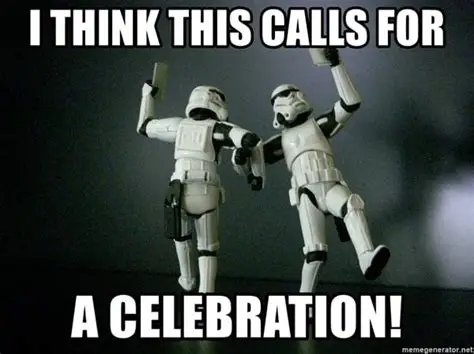

## Bonus: What's happening behind the scenes ?? (z-score)

A **z-score** tells us how many standard deviations a value is from the average.

It is calculated using:

$$z = \frac{x-\bar{x}} {s}$$

where:
* x = the point of interest (poi)
* $\bar{x}$ = average (avg)
* s = sample standard deviation (sd)

Using the earlier example:
```
x = 169
x_bar = 175
s = 7
```

Then:
    
```    
z = (169 - 175) / 7
z = -0.857
```

The negative sign tells us the value is below the average, while the magnitude (0.857) tells us it is about **0.86 standard deviations** away from the mean. In other words, the z-score measures how far a value is from the average in terms of standard deviations.

The norm_dist() function calculates the z-score automatically behind the scenes, so we don't need to compute it ourselves. This is why the function requires both the average and standard deviation as inputs.

The following task is a bonus and not required, but completing it will earn you bonus points.

In [16]:
# find the z-score for the poi of 39
# in terms of the temperature of students

# BONUS TODO [+0.5 bonus pts]
# 1) use the poi value, avg, and sd to find the z-score [+0.5 bonus pts]
z_score = (39 - average(data_list)) / sample_sd(data_list)

# printing z-score
print(f"z-score = {z_score}")

z-score = 1.7986143199388107
